In [1]:
%load_ext autoreload
%autoreload 2
# import jtplot submodule from jupyterthemes
# from jupyterthemes import jtplot
# jtplot.style()
%load_ext tensorboard

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("..") # Add s higher directory to python modules path.
from environment.environment import *
from engine.agent.base_agent import *
from engine.policy.base_policy import *
np.set_printoptions(suppress=True)

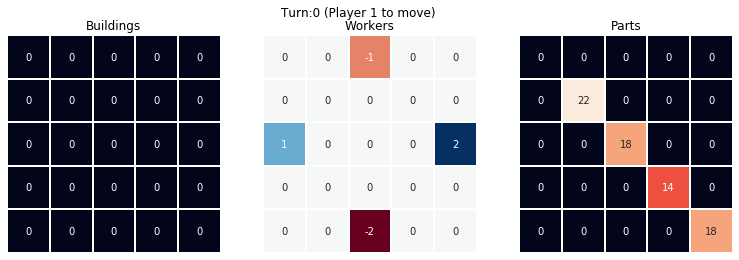

In [4]:
env = Santorini()
env.print_board(mode=1)

# Environment Testing

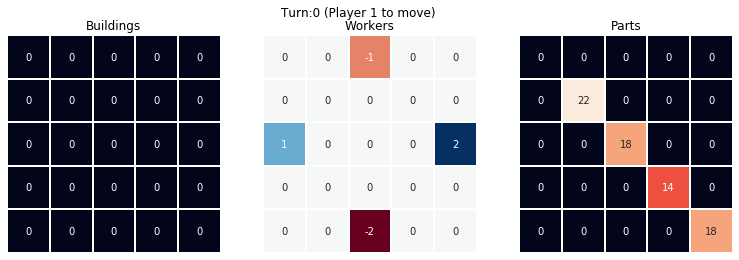

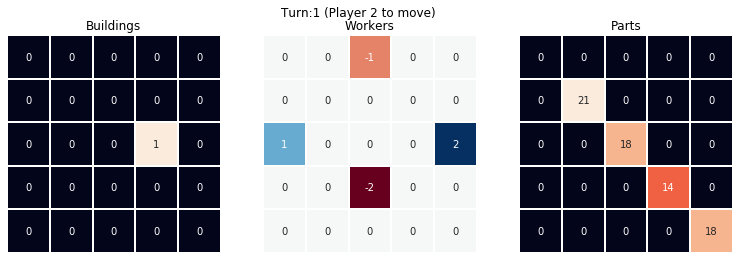

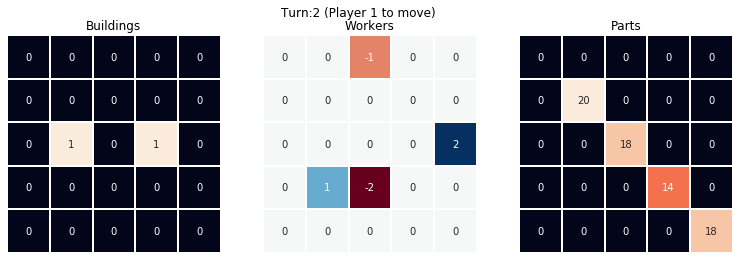

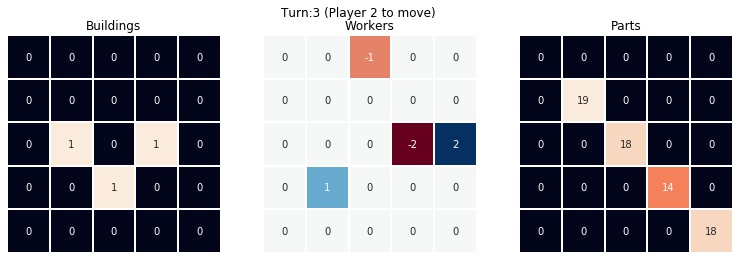

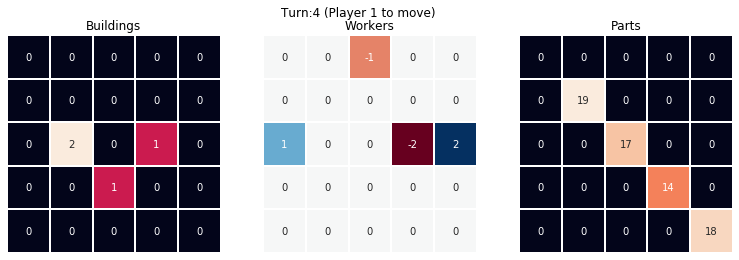

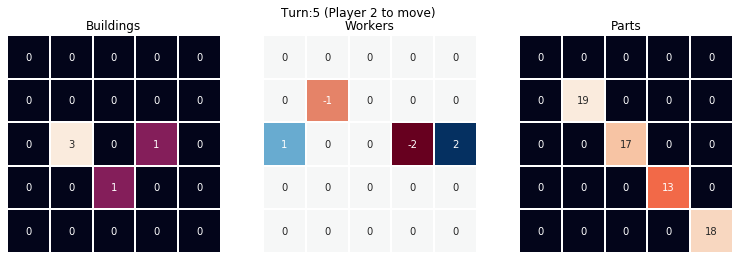

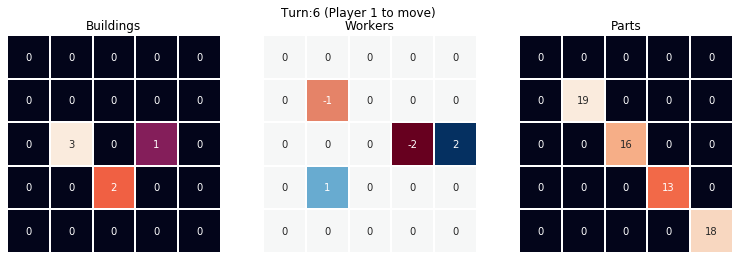

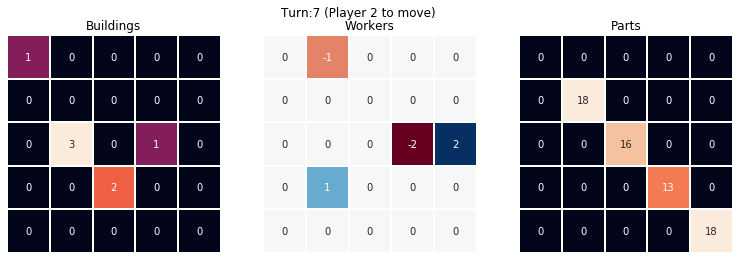

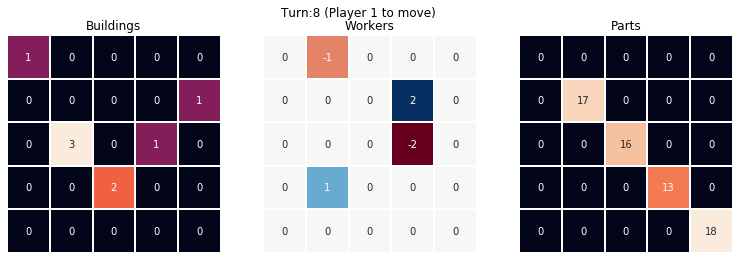

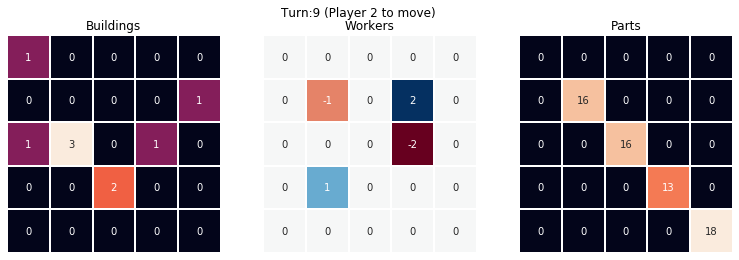

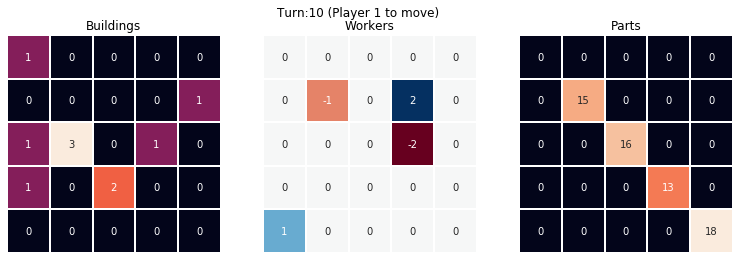

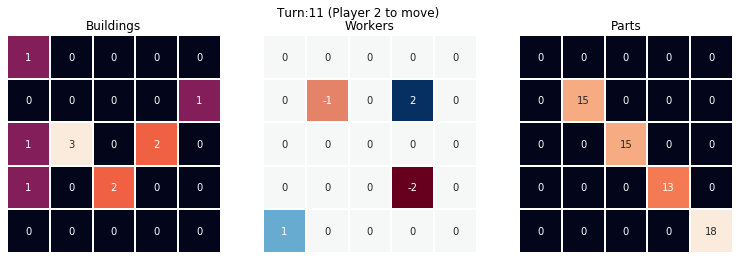

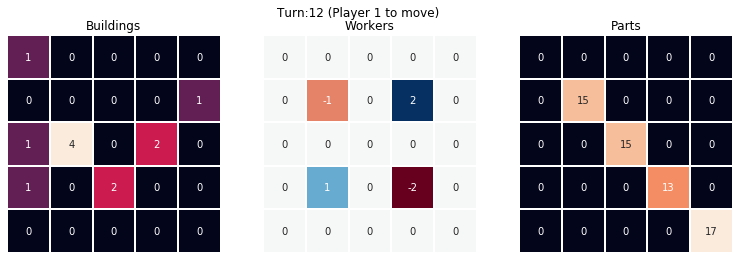

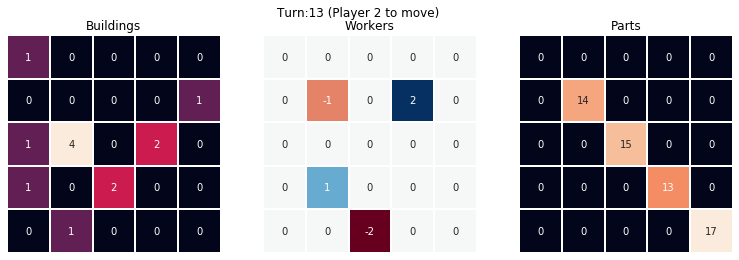

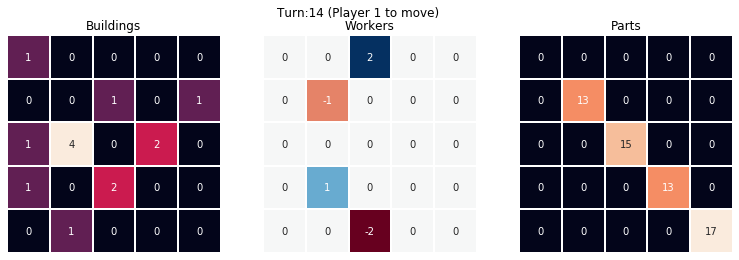

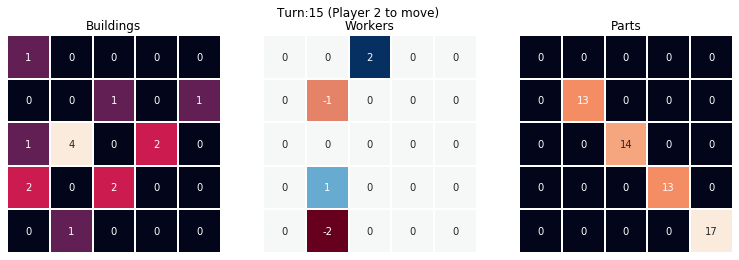

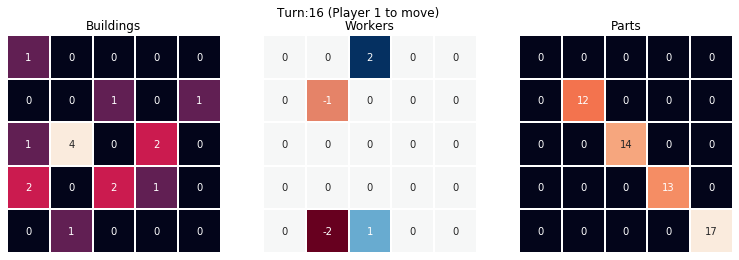

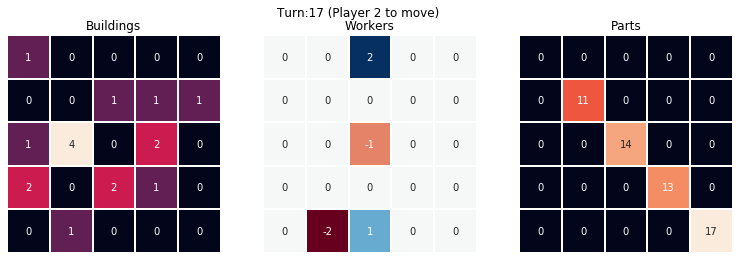

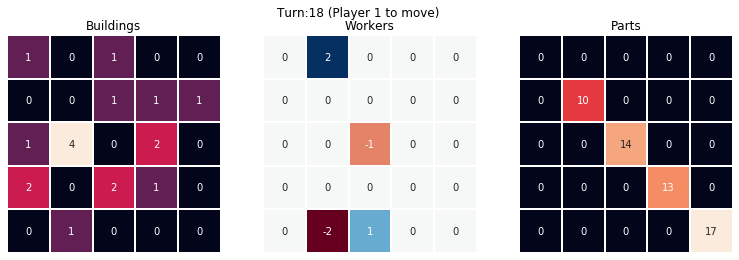

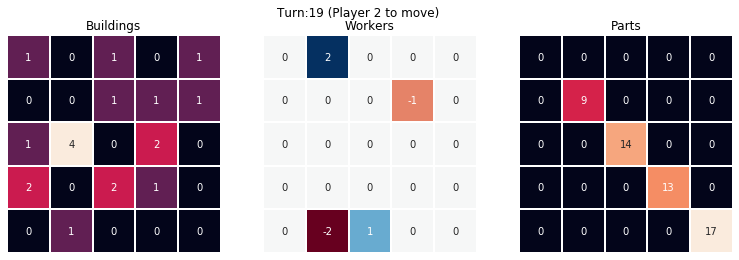

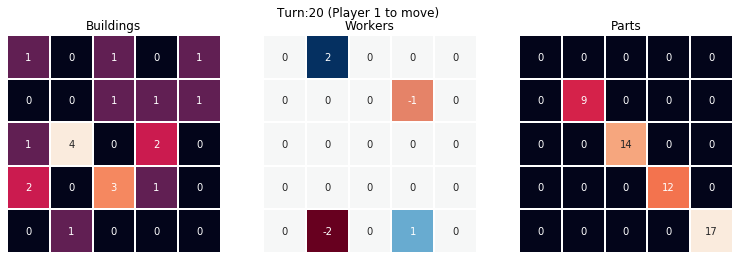

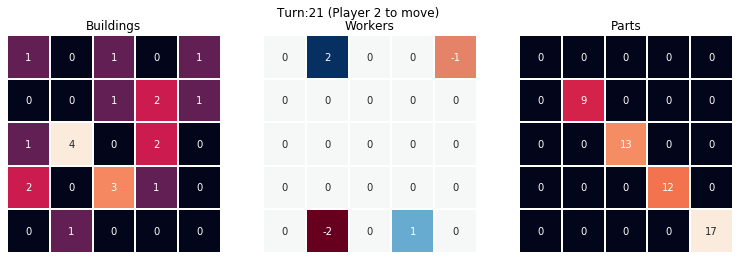

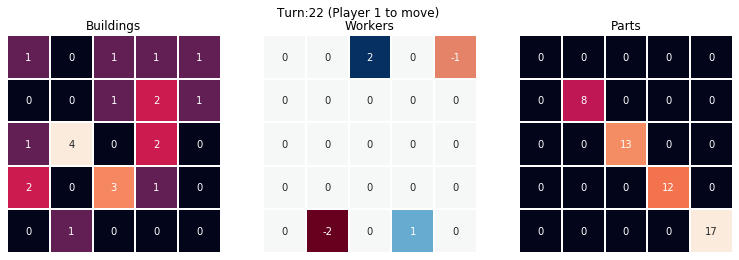

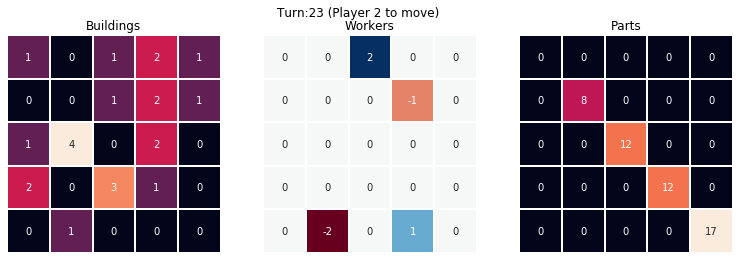

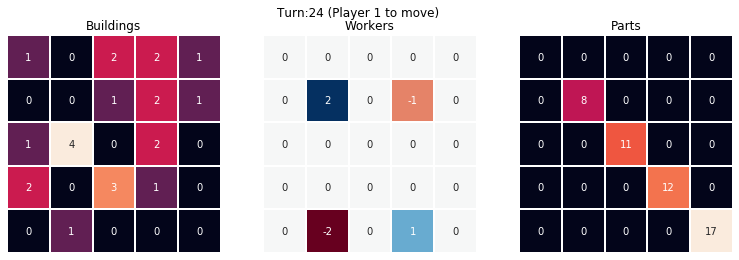

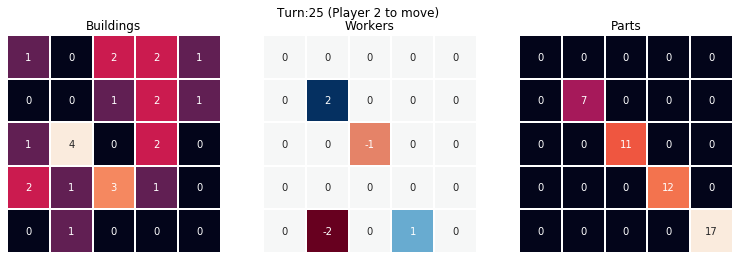

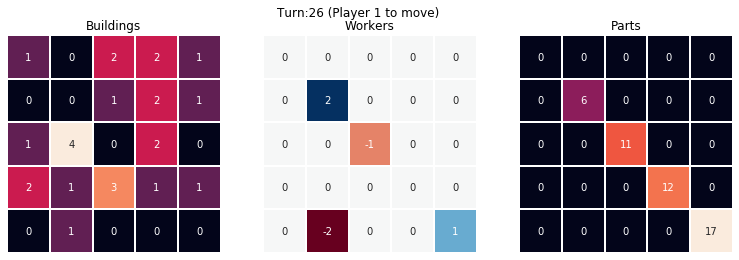

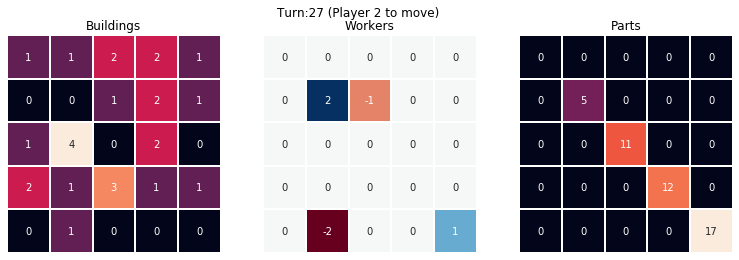

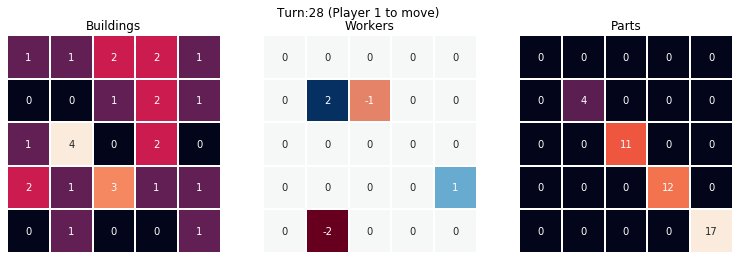

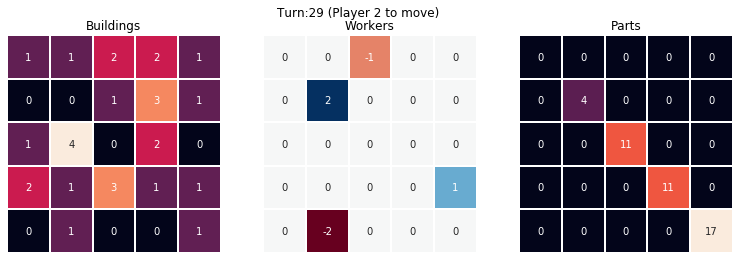

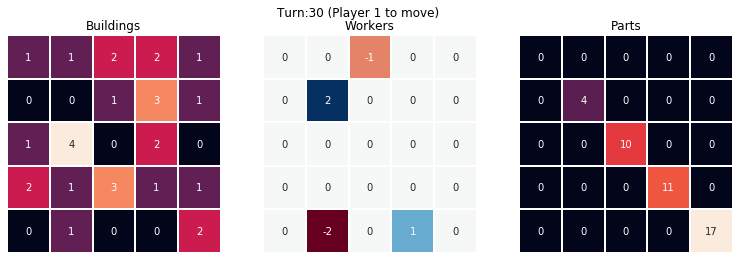

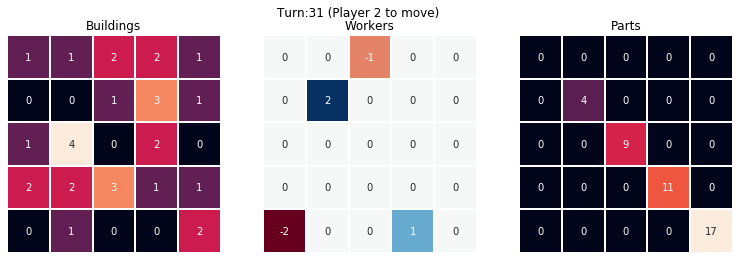

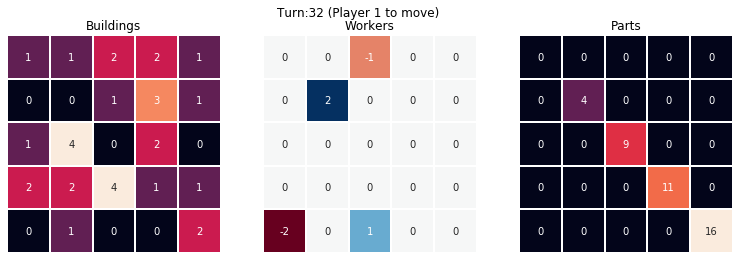

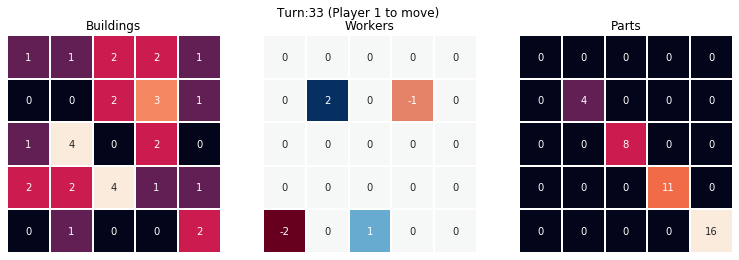

Player1 has won


In [15]:
#initiate env
env = Santorini()
env.reset()
policy = RandomPolicy()
player1 = OneStepAgent(policy, -1)
player2 = OneStepAgent(policy,  1)
n_eps = 1
done = False
while True:
    env.print_board(mode=1)
    if current_player == -1:
        s, a, r, done, _ = player1.step(env)
    else:
        s, a, r, done, _ = player2.step(env)
    
    winner = env.check_winner()
    if winner == -1:
        env.print_board(mode=1)
        print('Player1 has won')
        break
    elif winner == 1:
        env.print_board(mode=1)
        print('Player2 has won')
        break


# Random Baseline

# Training Loop

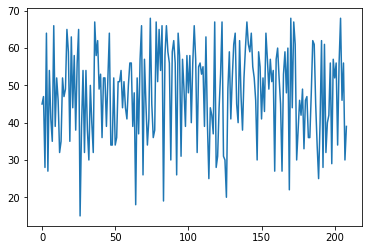

In [136]:
plt.plot(np.arange(len(turns)), turns)

In [32]:
from engine.network import *

model = ToyConvNet().get_model()
model.summary()

Model: "ToyConvNet"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_8 (InputLayer)         [(None, 5, 5, 3)]         0         
_________________________________________________________________
conv2d_143 (Conv2D)          (None, 5, 5, 16)          1216      
_________________________________________________________________
batch_normalization_229 (Bat (None, 5, 5, 16)          64        
_________________________________________________________________
activation_222 (Activation)  (None, 5, 5, 16)          0         
_________________________________________________________________
conv2d_144 (Conv2D)          (None, 5, 5, 32)          12832     
_________________________________________________________________
batch_normalization_230 (Bat (None, 5, 5, 32)          128       
_________________________________________________________________
activation_223 (Activation)  (None, 5, 5, 32)          0

In [34]:
model.predict(env.get_converted_board().reshape(1, 5, 5, 3))

array([[0.00880379, 0.00764936, 0.00638985, 0.00725979, 0.0071122 ,
        0.00740534, 0.00808571, 0.00691857, 0.00803332, 0.00910633,
        0.00807919, 0.00897849, 0.00799997, 0.00723343, 0.00775352,
        0.00896682, 0.00823442, 0.00807884, 0.0080339 , 0.00884784,
        0.00871148, 0.00643253, 0.0084257 , 0.00626082, 0.00665307,
        0.00733281, 0.00831687, 0.00844989, 0.00738389, 0.00765683,
        0.00832386, 0.00849544, 0.00859377, 0.00817023, 0.00895773,
        0.00850828, 0.00629239, 0.00822386, 0.00758888, 0.00744403,
        0.00805332, 0.00784996, 0.0082248 , 0.00743987, 0.0083964 ,
        0.00912254, 0.00770643, 0.00769117, 0.00894287, 0.00872261,
        0.00727857, 0.00820238, 0.00753832, 0.00764373, 0.00671881,
        0.0073404 , 0.00657278, 0.00837359, 0.00737653, 0.00695296,
        0.00777553, 0.00752303, 0.00805897, 0.00682837, 0.00849896,
        0.00742206, 0.00924433, 0.0085067 , 0.0084036 , 0.00737628,
        0.00711111, 0.00714552, 0.00881444, 0.00

In [41]:
model = ResNet19().get_model()
model.summary()

Model: "ResNet19"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_12 (InputLayer)           [(None, 5, 5, 3)]    0                                            
__________________________________________________________________________________________________
conv2d_214 (Conv2D)             (None, 5, 5, 256)    7168        input_12[0][0]                   
__________________________________________________________________________________________________
batch_normalization_358 (BatchN (None, 5, 5, 256)    1024        conv2d_214[0][0]                 
__________________________________________________________________________________________________
activation_353 (Activation)     (None, 5, 5, 256)    0           batch_normalization_358[0][0]    
___________________________________________________________________________________________

In [45]:
model.predict(env.get_converted_board().reshape(1, 5, 5, 3))

[array([[0.00781243, 0.00781263, 0.00781227, 0.00781263, 0.00781275,
         0.00781245, 0.00781262, 0.00781231, 0.0078126 , 0.00781255,
         0.00781231, 0.0078126 , 0.00781241, 0.00781242, 0.00781224,
         0.00781262, 0.00781221, 0.00781239, 0.00781255, 0.00781259,
         0.00781262, 0.00781247, 0.00781249, 0.00781257, 0.00781252,
         0.00781242, 0.00781253, 0.00781246, 0.00781244, 0.00781248,
         0.00781247, 0.00781251, 0.00781287, 0.00781233, 0.00781264,
         0.00781254, 0.00781249, 0.0078123 , 0.00781238, 0.00781244,
         0.00781241, 0.00781253, 0.00781251, 0.00781247, 0.00781243,
         0.00781242, 0.00781252, 0.00781246, 0.00781251, 0.00781263,
         0.00781238, 0.00781232, 0.00781273, 0.00781273, 0.00781235,
         0.00781256, 0.0078123 , 0.00781247, 0.00781245, 0.0078125 ,
         0.0078124 , 0.00781245, 0.00781251, 0.0078122 , 0.00781245,
         0.0078127 , 0.00781247, 0.00781246, 0.00781258, 0.0078127 ,
         0.00781263, 0.0078128 , 0